<a href="https://colab.research.google.com/github/vinay869/Predicting-High-risk-pregnancies-using-ML-on-maternal-Health-Indicators/blob/main/Predicting%20high%20risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predicting High-Risk Pregnancies Using Machine Learning on Maternal Health Indicators**

# **Importing Files**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set plotting style
sns.set(style="whitegrid")

# Load the dataset (skipping the title row)
df = pd.read_excel('Book2.xlsx', skiprows=1)

# **Data Cleaning**
To visualize the numerical data (like Blood Pressure, Weight, and Height) and the Target variable, we must first clean the strings and convert them to numeric types.

In [2]:
# Rename columns for easier access
column_mapping = {
    'Name': 'Name', 'Age': 'Age', 'Gravida': 'Gravida', 'TiTi Tika': 'TT_Vaccine',
    'গর্ভকাল': 'Gestational_Age', 'ওজন': 'Weight', 'উচ্চতা': 'Height',
    'রক্ত চাপ': 'Blood_Pressure', 'রক্তস্বল্পতা': 'Anemia', 'জন্ডিস': 'Jaundice',
    'গর্ভস্হ শিশু অবস্থান': 'Fetal_Position', 'গর্ভস্হ শিশু নাড়াচাড়া': 'Fetal_Movement',
    'গর্ভস্হ শিশু হৃৎস্পন্দন': 'Fetal_Heart_Rate', 'প্রসাব পরিক্ষা এলবুমিন': 'Urine_Albumin',
    'প্রসাব পরিক্ষা সুগার': 'Urine_Sugar', 'VDRL': 'VDRL', 'HRsAG': 'HBsAg', 'ঝুকিপূর্ণ গর্ভ': 'Risk_Status'
}
df.rename(columns=column_mapping, inplace=True)

# Helper functions to extract numbers
def extract_num(val):
    match = re.search(r'(\d+)', str(val))
    return int(match.group(1)) if match else np.nan

def extract_float(val):
    match = re.search(r"(\d+\.\d+)", str(val))
    return float(match.group(1)) if match else np.nan

# Clean numeric columns
df['Weight_kg'] = df['Weight'].apply(extract_num)
df['Height_ft'] = df['Height'].apply(extract_float)
df['FHR_bpm'] = df['Fetal_Heart_Rate'].apply(extract_num)
df['GA_weeks'] = df['Gestational_Age'].apply(extract_num)

# Split Blood Pressure into Systolic and Diastolic
df[['Systolic', 'Diastolic']] = df['Blood_Pressure'].str.split('/', expand=True).astype(float)

# Handle missing values in clinical tests (Treating 'NaN' as 'None/Normal')
cols_to_fill = ['Anemia', 'Jaundice', 'Urine_Albumin']
for col in cols_to_fill:
    df[col] = df[col].fillna('None')

# Feature Engineering: BMI
# Conversion: Height in feet to meters, Weight in kg is already metric
df['BMI'] = df['Weight_kg'] / ((df['Height_ft'] * 0.3048) ** 2)

# Drop non-predictive columns
df.drop(['Name', 'Weight', 'Height', 'Blood_Pressure', 'Gestational_Age', 'Fetal_Heart_Rate'], axis=1, inplace=True)

In [3]:
df.head()

,Age,Gravida,TT_Vaccine,Anemia,Jaundice,Fetal_Position,Fetal_Movement,Urine_Albumin,Urine_Sugar,VDRL,HBsAg,Risk_Status,Weight_kg,Height_ft,FHR_bpm,GA_weeks,Systolic,Diastolic,BMI
0,18,1st,1st,None,None,Normal,Normal,None,Yes,Negative,Negative,Yes,50,5.3,140,38,100.0,60.0,19.159684
1,25,2nd,2nd,None,None,Normal,Normal,None,Yes,Positive,Negative,No,60,5.2,130,38,100.0,70.0,23.884417
2,20,1st,1st,None,None,Normal,Normal,None,Yes,Negative,Negative,Yes,55,5.0,120,30,100.0,60.0,23.680603
3,22,1st,3rd,None,None,Normal,Normal,None,Yes,Positive,Negative,Yes,51,5.4,130,35,110.0,65.0,18.825769
4,20,1st,2nd,None,None,Normal,Normal,None,Yes,Negative,Negative,No,53,5.2,125,30,100.0,55.0,21.097901


# **Exploratory Data Analysis**

In [4]:
df.describe()

,Age,Weight_kg,Height_ft,FHR_bpm,GA_weeks,Systolic,Diastolic,BMI
count,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000
mean,22.962926,56.114228,5.249699,132.279559,28.938878,102.825651,64.574148,21.982209
std,3.568168,5.308816,0.162894,8.889661,4.969241,9.343101,7.914032,2.508065
min,18.000000,45.000000,5.000000,120.000000,20.000000,80.000000,55.000000,15.445662
25%,20.000000,52.000000,5.100000,125.000000,25.000000,100.000000,60.000000,20.278032
50%,22.000000,56.000000,5.200000,130.000000,30.000000,100.000000,60.000000,21.933381
75%,25.000000,61.000000,5.400000,140.000000,32.000000,110.000000,70.000000,23.884417
max,32.000000,65.000000,5.600000,150.000000,38.000000,120.000000,80.000000,27.986167


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             998 non-null    int64  
 1   Gravida         998 non-null    object 
 2   TT_Vaccine      998 non-null    object 
 3   Anemia          998 non-null    object 
 4   Jaundice        998 non-null    object 
 5   Fetal_Position  998 non-null    object 
 6   Fetal_Movement  998 non-null    object 
 7   Urine_Albumin   998 non-null    object 
 8   Urine_Sugar     998 non-null    object 
 9   VDRL            998 non-null    object 
 10  HBsAg           998 non-null    object 
 11  Risk_Status     998 non-null    object 
 12  Weight_kg       998 non-null    int64  
 13  Height_ft       998 non-null    float64
 14  FHR_bpm         998 non-null    int64  
 15  GA_weeks        998 non-null    int64  
 16  Systolic        998 non-null    float64
 17  Diastolic       998 non-null    flo

## **Missing Values Check**
This block identifies which columns have null values and calculates their percentage.

In [6]:
# Check for missing values
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({'Total Missing': missing_data, 'Percentage (%)': missing_percent})
print("Missing Values Summary:")
print(missing_df[missing_df['Total Missing'] > 0])

Missing Values Summary:
Empty DataFrame
Columns: [Total Missing, Percentage (%)]
Index: []


## **Target Distribution**
This block visualizes the balance between High-Risk ("Yes") and Low-Risk ("No") cases.

/tmp/ipykernel_2483/3082946495.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Risk_Status', data=df, palette='viridis')


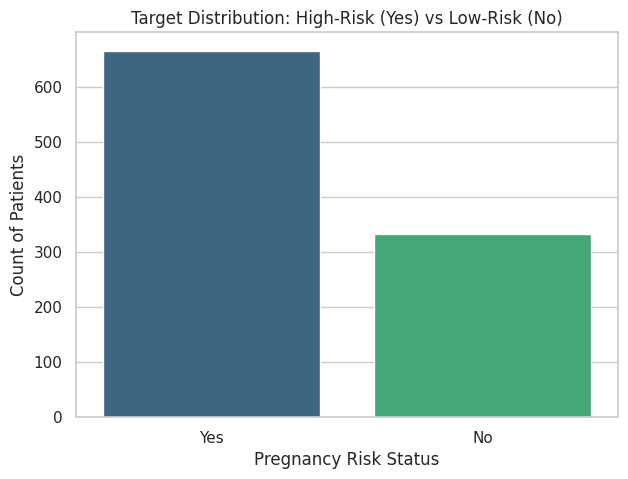

In [7]:
plt.figure(figsize=(7, 5))
sns.countplot(x='Risk_Status', data=df, palette='viridis')
plt.title('Target Distribution: High-Risk (Yes) vs Low-Risk (No)')
plt.xlabel('Pregnancy Risk Status')
plt.ylabel('Count of Patients')
plt.show()

## **Correlation Heatmap**
This heatmap shows the relationship between all numerical health indicators and the risk status.

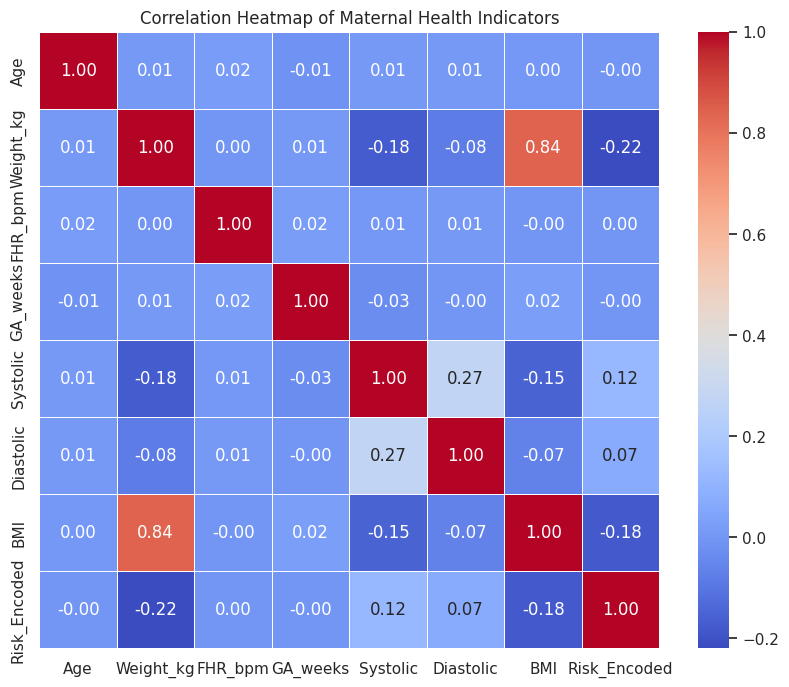

In [8]:
# Encode Target for correlation: Yes -> 1, No -> 0
numeric_features = ['Age', 'Weight_kg', 'FHR_bpm', 'GA_weeks', 'Systolic', 'Diastolic', 'BMI']
corr_data = df[numeric_features].copy()
corr_data['Risk_Encoded'] = df['Risk_Status'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(10, 8))
sns.heatmap(corr_data.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Maternal Health Indicators')
plt.show()

## **Pairplot**
The pairplot allows you to see the distribution of single variables and the relationships between two variables simultaneously, colored by risk status.

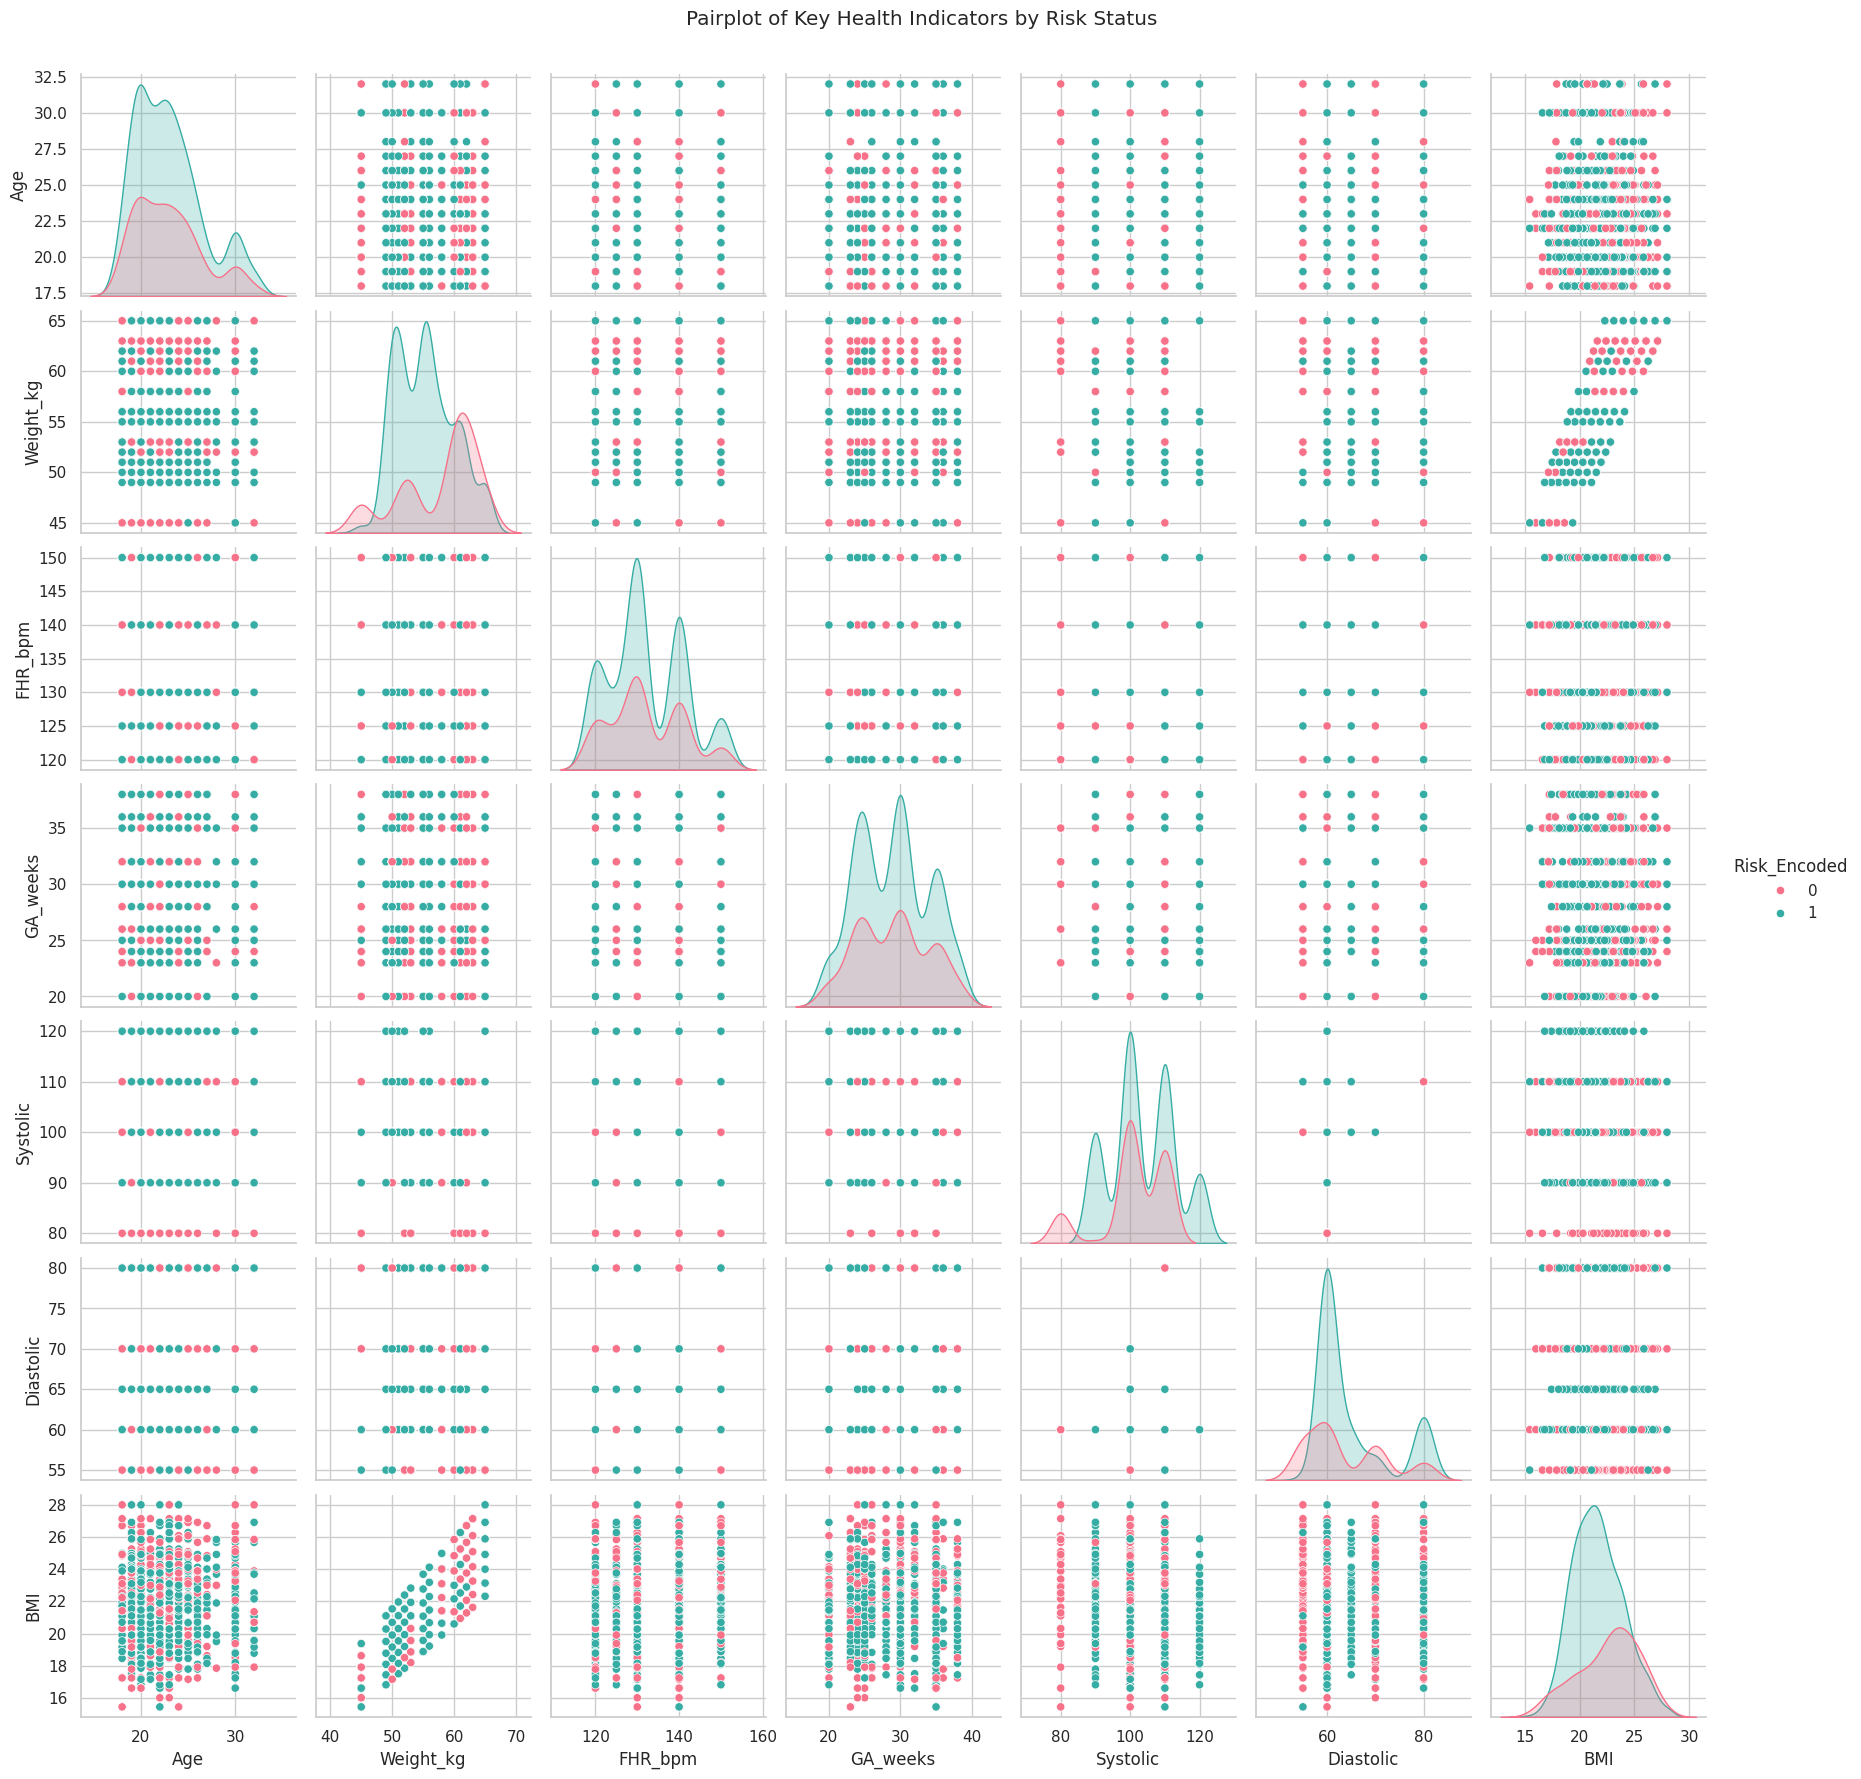

In [9]:
# Visualizing relationships across major numeric indicators
# We select a subset of features to keep the plot readable
sns.pairplot(corr_data, hue='Risk_Encoded', palette='husl', diag_kind='kde')
plt.suptitle('Pairplot of Key Health Indicators by Risk Status', y=1.02)
plt.show()

## **Box Plots (Numeric Indicators by Risk Status)**
Box plots are excellent for identifying the median, quartiles, and outliers of health indicators (like BP or BMI) across the two risk categories.

/tmp/ipykernel_2483/2355090768.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk_Status', y=col, data=df, palette='Set2')
/tmp/ipykernel_2483/2355090768.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk_Status', y=col, data=df, palette='Set2')
/tmp/ipykernel_2483/2355090768.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk_Status', y=col, data=df, palette='Set2')
/tmp/ipykernel_2483/2355090768.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assig

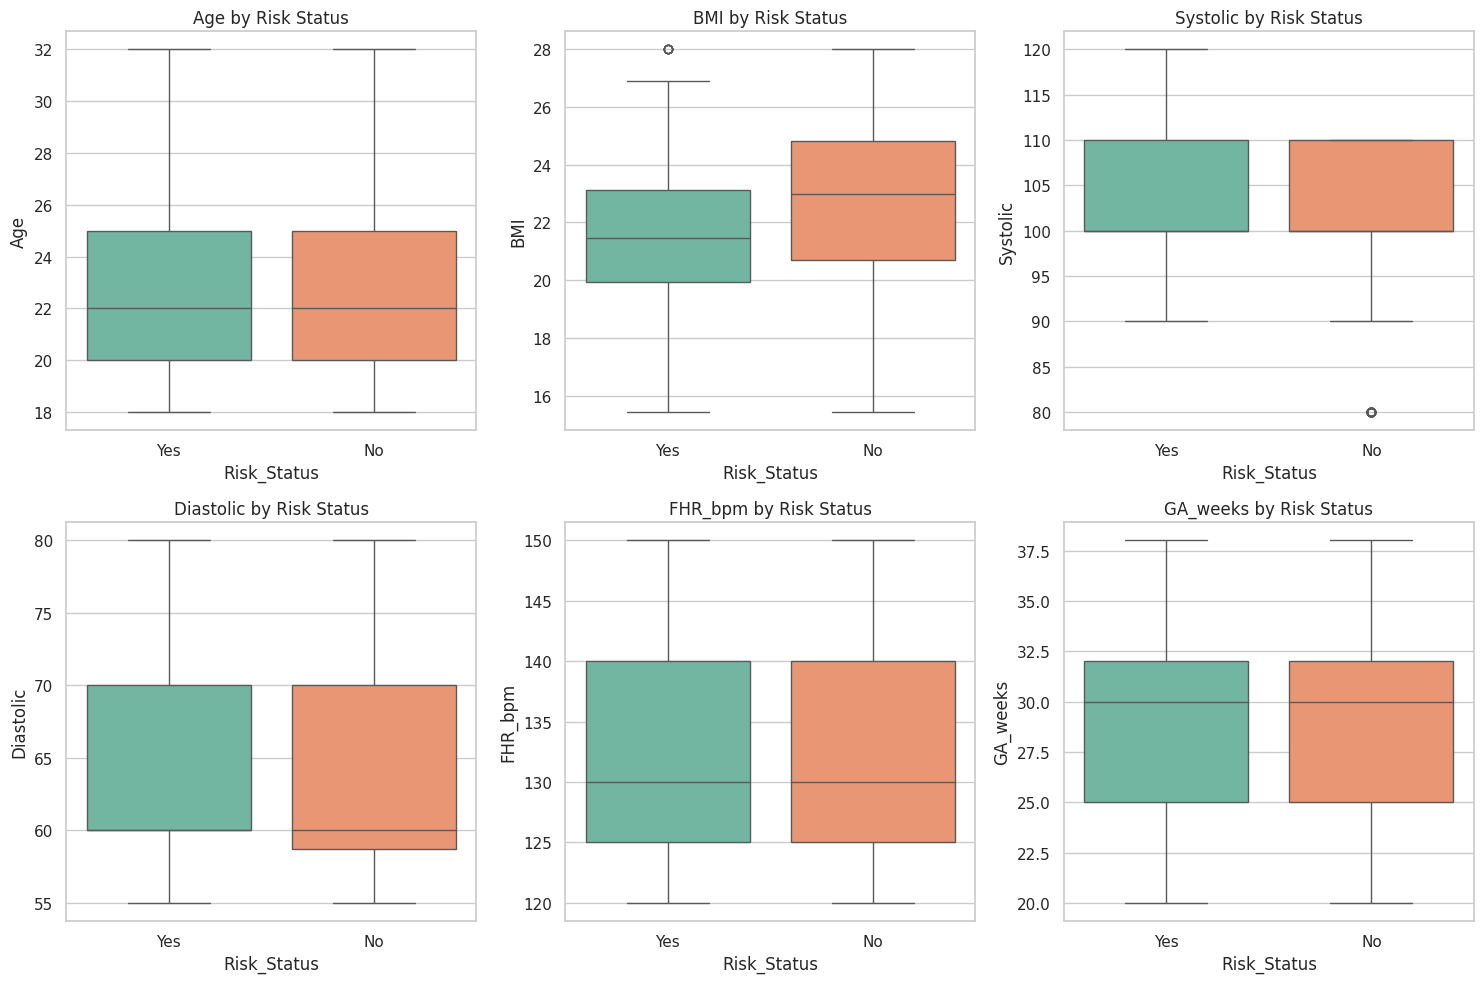

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numeric variables to compare
numeric_cols = ['Age', 'BMI', 'Systolic', 'Diastolic', 'FHR_bpm', 'GA_weeks']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='Risk_Status', y=col, data=df, palette='Set2')
    plt.title(f'{col} by Risk Status')

plt.tight_layout()
plt.show()

## **Gravida vs. Risk Status (Grouped Count Plot)**
This plot shows how the number of pregnancies (Gravida) relates to the high-risk outcome, helping to see if first-time mothers are at higher risk compared to others.

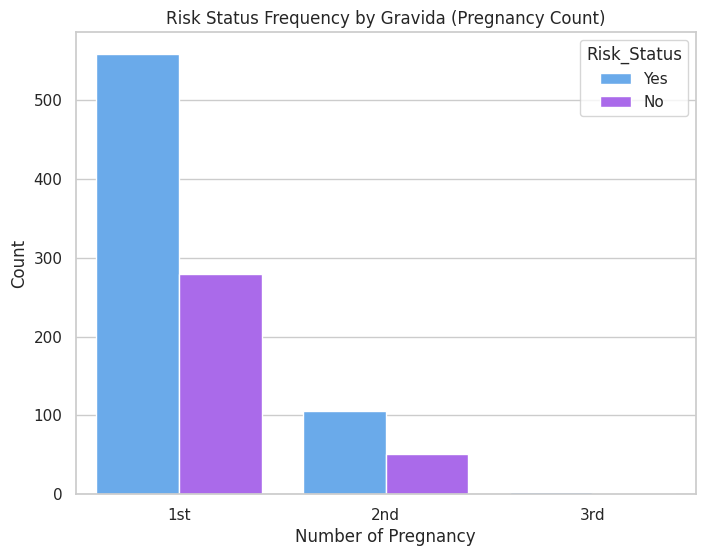

In [11]:
plt.figure(figsize=(8, 6))
# Ordering by pregnancy count
gravida_order = ['1st', '2nd', '3rd']

sns.countplot(x='Gravida', hue='Risk_Status', data=df,
              order=gravida_order, palette='cool')

plt.title('Risk Status Frequency by Gravida (Pregnancy Count)')
plt.xlabel('Number of Pregnancy')
plt.ylabel('Count')
plt.show()

#**Preprocessing**

In [12]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load your dataframe (assuming it is named df)
# df = pd.read_csv('maternal_health.csv')

# 1. Encoding Categorical Variables
le = LabelEncoder()
categorical_cols = ['Gravida', 'TT_Vaccine', 'Anemia', 'Jaundice', 'Fetal_Position',
                    'Fetal_Movement', 'Urine_Albumin', 'Urine_Sugar', 'VDRL', 'HBsAg', 'Risk_Status']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# 2. Define Features and Target
X = df.drop('Risk_Status', axis=1)
y = df['Risk_Status']

# 3. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scaling (Important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Model Training & Evaluation**

In [13]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42)
}

results = []
model_preds = {}
model_probs = {}

for name, model in models.items():
    # Training Time
    start_train = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start_train

    # Testing Time
    start_test = time.time()
    y_pred = model.predict(X_test_scaled)
    test_time = time.time() - start_test

    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Store for plotting
    model_preds[name] = y_pred
    model_probs[name] = y_prob

    # Metrics
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_prob),
        "Train Time (s)": round(train_time, 4),
        "Test Time (s)": round(test_time, 4)
    })

# Display Results Table
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1-Score   AUC-ROC  \
0        Random Forest     0.950   0.957143  0.971014  0.964029  0.993221   
1              XGBoost     0.975   0.971631  0.992754  0.982079  0.994390   
2  Logistic Regression     0.795   0.812903  0.913043  0.860068  0.846424   

   Train Time (s)  Test Time (s)  
0          0.2324         0.0175  
1          0.1406         0.0025  
2          0.0205         0.0004  


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:24:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## **Confusion Matix**

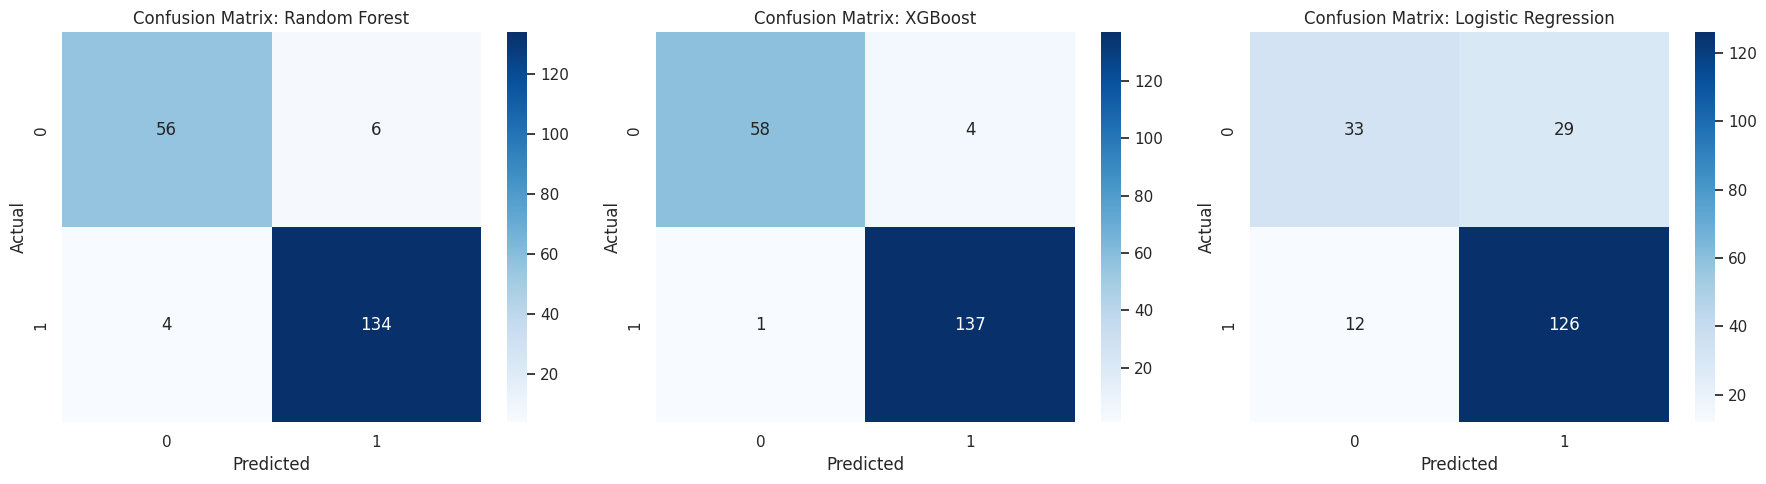

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, pred) in enumerate(model_preds.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues')
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## **Combined ROC Curve**

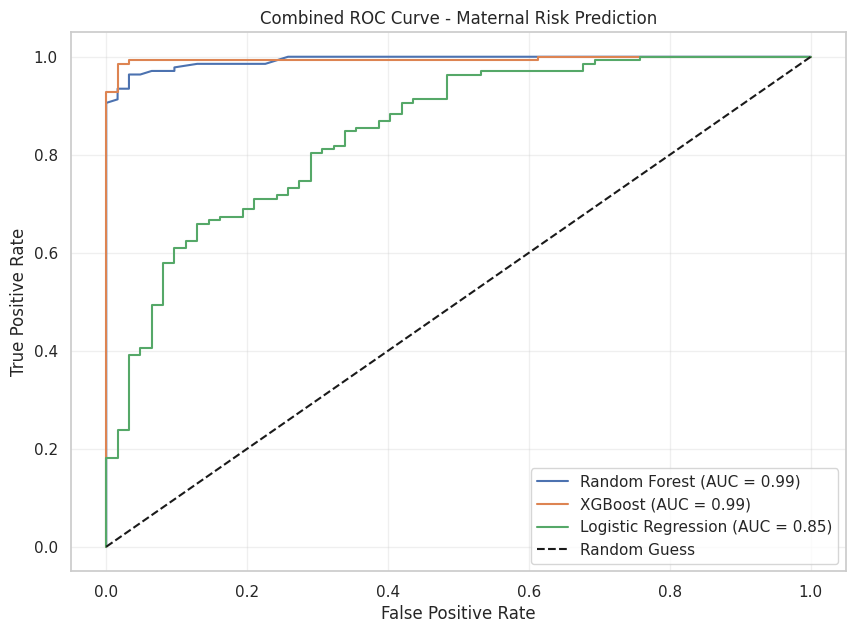

In [15]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 7))

for name, prob in model_probs.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Combined ROC Curve - Maternal Risk Prediction')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# **Hyperparameter Optimization using GridSearch**

In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
import pandas as pd

# 1. Define the models and the parameter grids to search through
model_tuning_config = {
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5, 10],
            'criterion': ['gini', 'entropy']
        }
    },
    'XGBoost': {
        'model': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 5, 7],
            'subsample': [0.8, 1.0]
        }
    },
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'C': [0.01, 0.1, 1, 10, 100],
            'solver': ['liblinear', 'lbfgs'],
            'penalty': ['l2'] # l2 is compatible with both solvers
        }
    }
}

# 2. Iterate through models, perform GridSearch, and store results
tuning_results = []

for model_name, config in model_tuning_config.items():
    print(f"Starting Hyperparameter Optimization for {model_name}...")

    # We use cv=5 (5-fold cross-validation) and optimize for 'f1'
    grid_search = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train_scaled, y_train)

    # Extract the best model and make predictions
    best_clf = grid_search.best_estimator_
    y_pred = best_clf.predict(X_test_scaled)

    # Collect metrics
    tuning_results.append({
        'Model': model_name,
        'Best Parameters': grid_search.best_params_,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

# 3. Create a summary DataFrame
performance_comparison = pd.DataFrame(tuning_results)

# Display the final results
print("\n" + "="*50)
print("FINAL EVALUATION AFTER HYPERPARAMETER TUNING")
print("="*50)
print(performance_comparison[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']])

# To see the best parameters for each:
for index, row in performance_comparison.iterrows():
    print(f"\nBest {row['Model']} Params: {row['Best Parameters']}")

Starting Hyperparameter Optimization for Random Forest...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Starting Hyperparameter Optimization for XGBoost...
Fitting 5 folds for each of 54 candidates, totalling 270 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:25:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Starting Hyperparameter Optimization for Logistic Regression...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

FINAL EVALUATION AFTER HYPERPARAMETER TUNING
                 Model  Accuracy  Precision    Recall  F1-Score
0        Random Forest     0.950   0.963768  0.963768  0.963768
1              XGBoost     0.965   0.971223  0.978261  0.974729
2  Logistic Regression     0.795   0.783626  0.971014  0.867314

Best Random Forest Params: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}

Best XGBoost Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50, 'subsample': 0.8}

Best Logistic Regression Params: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}


## **K-Fold Cross Validation**

In [17]:
from sklearn.model_selection import cross_validate, KFold
import pandas as pd

# 1. Initialize the models using the BEST parameters found in your previous step
best_models = {
    "Random Forest": RandomForestClassifier(
        criterion='entropy', max_depth=None, min_samples_split=5, n_estimators=100, random_state=42
    ),
    "XGBoost": XGBClassifier(
        learning_rate=0.1, max_depth=5, n_estimators=50, subsample=0.8, eval_metric='logloss', random_state=42
    ),
    "Logistic Regression": LogisticRegression(
        C=0.01, penalty='l2', solver='lbfgs', max_iter=1000, random_state=42
    )
}

# 2. Define the K-Fold strategy (e.g., 10 folds)
kf = KFold(n_splits=10, shuffle=True, random_state=42)

cv_results = []

print("Running 10-Fold Cross-Validation...")

for name, model in best_models.items():
    # We evaluate multiple metrics at once
    metrics = ['accuracy', 'precision', 'recall', 'f1']
    cv_score = cross_validate(model, X_train_scaled, y_train, cv=kf, scoring=metrics)

    cv_results.append({
        "Model": name,
        "Avg Accuracy": cv_score['test_accuracy'].mean(),
        "Avg Precision": cv_score['test_precision'].mean(),
        "Avg Recall": cv_score['test_recall'].mean(),
        "Avg F1-Score": cv_score['test_f1'].mean(),
        "Std Dev (Accuracy)": cv_score['test_accuracy'].std()
    })

# 3. Display CV Results
cv_df = pd.DataFrame(cv_results)
print("\n" + "="*60)
print("10-FOLD CROSS-VALIDATION RESULTS (AVERAGED)")
print("="*60)
print(cv_df.to_string(index=False))

Running 10-Fold Cross-Validation...

10-FOLD CROSS-VALIDATION RESULTS (AVERAGED)
              Model  Avg Accuracy  Avg Precision  Avg Recall  Avg F1-Score  Std Dev (Accuracy)
      Random Forest      0.951123       0.958107    0.969392      0.963404            0.036438
            XGBoost      0.973703       0.984309    0.975170      0.979665            0.029809
Logistic Regression      0.770680       0.760784    0.952725      0.845648            0.032091


# **Impact of Class Balance on Accuracy**

In [18]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
import pandas as pd

# 1. Apply SMOTE to the training data only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# 2. Define the optimized models
balanced_models = {
    "Random Forest": RandomForestClassifier(criterion='entropy', max_depth=None, min_samples_split=5, n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(learning_rate=0.1, max_depth=5, n_estimators=50, subsample=0.8, random_state=42),
    "Logistic Regression": LogisticRegression(C=0.01, penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)
}

smote_results = []

for name, model in balanced_models.items():
    # Fit on SMOTE data
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test_scaled)

    smote_results.append({
        "Model": name,
        "Accuracy (SMOTE)": accuracy_score(y_test, y_pred),
        "Precision (SMOTE)": precision_score(y_test, y_pred),
        "Recall (SMOTE)": recall_score(y_test, y_pred),
        "F1-Score (SMOTE)": f1_score(y_test, y_pred)
    })

# 3. Combine with your previous non-SMOTE results for a direct comparison
smote_df = pd.DataFrame(smote_results)

print("--- Comparison: Performance with SMOTE Balancing ---")
print(smote_df.to_string(index=False))

# 4. Quick visual comparison of Recall change (Example for one model)
print(f"\nObservation: If Recall (SMOTE) > Previous Recall, SMOTE successfully improved")
print(f"the model's ability to identify High-Risk cases.")

--- Comparison: Performance with SMOTE Balancing ---
              Model  Accuracy (SMOTE)  Precision (SMOTE)  Recall (SMOTE)  F1-Score (SMOTE)
      Random Forest             0.950           0.963768        0.963768          0.963768
            XGBoost             0.980           0.992647        0.978261          0.985401
Logistic Regression             0.775           0.854962        0.811594          0.832714

Observation: If Recall (SMOTE) > Previous Recall, SMOTE successfully improved
the model's ability to identify High-Risk cases.


--- XGBoost Sensitivity Comparison ---
Recall (Original): 0.9783
Recall (With SMOTE): 0.9783

Detailed Classification Report (With SMOTE):
              precision    recall  f1-score   support

           0       0.95      0.98      0.97        62
           1       0.99      0.98      0.99       138

    accuracy                           0.98       200
   macro avg       0.97      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



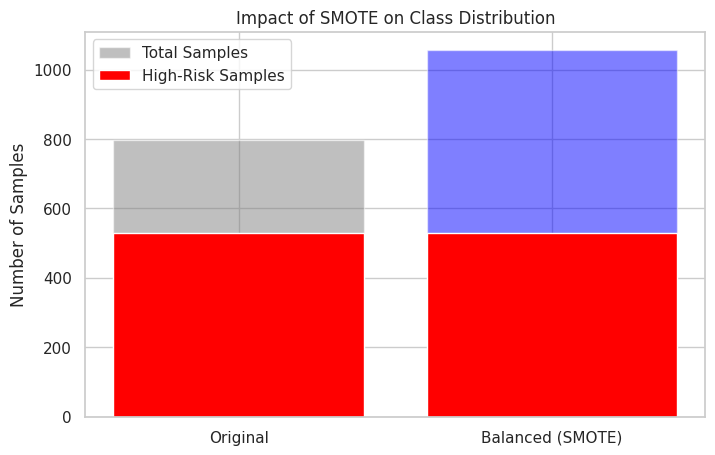

In [19]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, recall_score
import matplotlib.pyplot as plt

# 1. Initialize SMOTE and the Best Model (XGBoost based on your previous results)
smote = SMOTE(random_state=42)
best_model_name = "XGBoost"
clf_balanced = XGBClassifier(learning_rate=0.1, max_depth=5, n_estimators=50, subsample=0.8, random_state=42)

# 2. Resample the training data
X_resampled, y_resampled = smote.fit_resample(X_train_scaled, y_train)

# 3. Train on Original Data vs SMOTE Data
# Original
clf_balanced.fit(X_train_scaled, y_train)
y_pred_orig = clf_balanced.predict(X_test_scaled)
recall_orig = recall_score(y_test, y_pred_orig)

# SMOTE
clf_balanced.fit(X_resampled, y_resampled)
y_pred_smote = clf_balanced.predict(X_test_scaled)
recall_smote = recall_score(y_test, y_pred_smote)

# 4. Compare Results
print(f"--- {best_model_name} Sensitivity Comparison ---")
print(f"Recall (Original): {recall_orig:.4f}")
print(f"Recall (With SMOTE): {recall_smote:.4f}")
print("\nDetailed Classification Report (With SMOTE):")
print(classification_report(y_test, y_pred_smote))

# 5. Visualization of Class Distribution
labels = ['Original High-Risk', 'SMOTE High-Risk']
counts = [sum(y_train == 1), sum(y_resampled == 1)]

plt.figure(figsize=(8, 5))
plt.bar(['Original', 'Balanced (SMOTE)'], [len(y_train), len(y_resampled)], color=['gray', 'blue'], alpha=0.5, label='Total Samples')
plt.bar(['Original', 'Balanced (SMOTE)'], [sum(y_train==1), sum(y_resampled==1)], color=['red'], label='High-Risk Samples')
plt.title("Impact of SMOTE on Class Distribution")
plt.ylabel("Number of Samples")
plt.legend()
plt.show()

# **Significant Indicators**

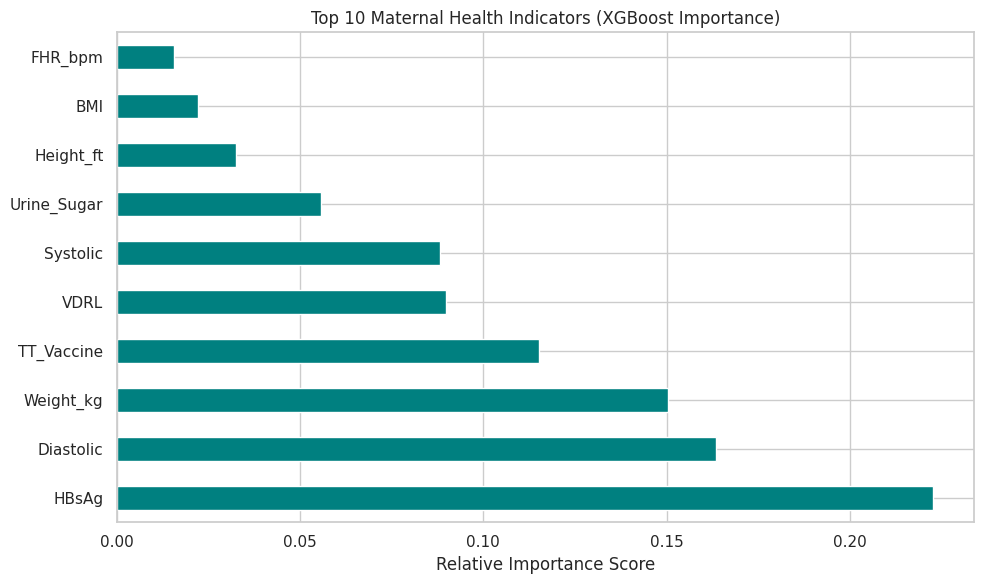

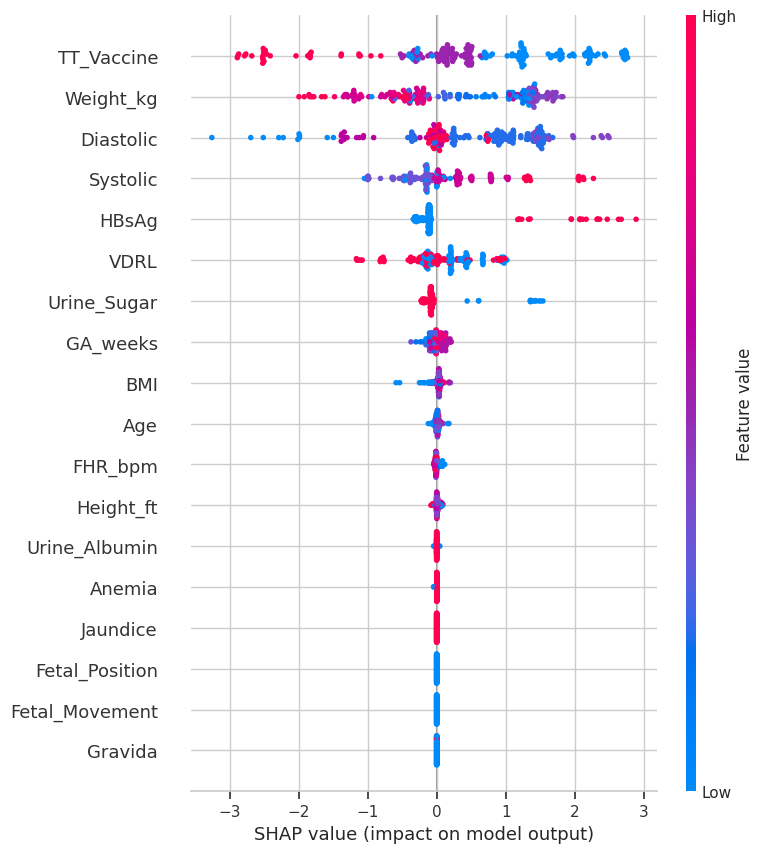

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb
import shap

# 1. Train the best XGBoost model (using SMOTE-balanced data for best results)
xgb_model = XGBClassifier(learning_rate=0.1, max_depth=5, n_estimators=50, subsample=0.8, random_state=42)
xgb_model.fit(X_train_smote, y_train_smote)

# 2. Traditional XGBoost Feature Importance
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title("Top 10 Maternal Health Indicators (XGBoost Importance)")
plt.xlabel("Relative Importance Score")
plt.tight_layout()
plt.show()

# 3. SHAP Values Calculation
# We use the scaled test data to see how the model behaves on 'new' patients
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)

# 4. SHAP Summary Plot
# This shows the distribution of the impact each feature has on the model output
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)